# Province MFCC Baseline — Reporting Notebook

This notebook reproduces the baseline run from `train_province_mfcc_baseline.py` and adds reporting visuals:

- Class distribution after filtering/capping
- Fold-level accuracy
- Overall + normalized confusion matrices
- Per-class precision/recall/F1

Run cells top-to-bottom. Edit the configuration + feature-building section to match your script.


In [30]:
import os
import sys
from pathlib import Path

import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

SCRIPT_PATH = Path("train_province_mfcc_baseline.py").resolve()
print("Script path:", SCRIPT_PATH)
print("Python:", sys.version)

Script path: /Users/cianan/Documents/College/GitHub/FYP/Prototype2/Scripts/Notebooks/CurrentNotebook/train_province_mfcc_baseline.py
Python: 3.13.7 (main, Aug 14 2025, 11:12:11) [Clang 16.0.0 (clang-1600.0.26.6)]


## Configuration

Set your dataset paths + column names to match the script.
Use speaker-safe splits (`GroupKFold`) for speech data so the same speaker never appears in both train and test.


In [31]:
# Paths (edit)
INDEX_CSV = "/Users/cianan/Documents/College/GitHub/FYP/Prototype2/Data/speaker_master_clean_10s_lufs.csv"          # Path(".../your_index.csv").resolve()
AUDIO_BASE_DIR = None     # Only needed if you compute MFCCs from wav paths

# Column names in your index CSV
COL_PROVINCE = "native_province"     # or "native_province"
COL_SPEAKER  = "speaker"  # speaker id for grouping
COL_AUDIO    = "segment_file_clean" # wav path if computing MFCCs here

# Filters / caps (match your .py)
ALLOWED_PROVINCES = ["Connacht", "Leinster", "Munster", "Ulster"]
MAX_PER_PROVINCE = None       # e.g. 400, or None

# Cross-validation
N_SPLITS = 5
USE_GROUP_SPLIT = True  # recommended

# Baseline model (swap to match your script if needed)
BASELINE_MODEL = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

if(MAX_PER_PROVINCE != None):
    print("Max Per Province:", MAX_PER_PROVINCE)

print("Allowed provinces:", ALLOWED_PROVINCES)


Allowed provinces: ['Connacht', 'Leinster', 'Munster', 'Ulster']


## Load and filter the index

This should mirror the filtering/capping you do in the script.


In [32]:
if INDEX_CSV is None:
    raise ValueError("Set INDEX_CSV before running.")

df = pd.read_csv(INDEX_CSV).copy()
df[COL_PROVINCE] = df[COL_PROVINCE].astype(str).str.strip()

# 1) Filter to the 4 target provinces (same as the main experiment)
df = df[df[COL_PROVINCE].isin(ALLOWED_PROVINCES)].reset_index(drop=True)
print("Rows after province filter:", len(df))

# 2) EXP 03: Ulster vs Rest (binary label mapping)
df["province_binary"] = np.where(df[COL_PROVINCE] == "Ulster", "Ulster", "Other")
COL_TARGET = "province_binary"

# Optional cap per class (Ulster vs Other)
if MAX_PER_PROVINCE is not None:
    df = (
        df.groupby(COL_TARGET, group_keys=False)
          .head(MAX_PER_PROVINCE)
          .reset_index(drop=True)
    )
    print("Rows after cap:", len(df))

# Class counts for the binary task
class_counts = (
    df[COL_TARGET]
    .value_counts()
    .reindex(["Other", "Ulster"])
    .fillna(0)
    .astype(int)
)

print("Binary class counts:")
print(class_counts)

class_counts

print(df[COL_TARGET].value_counts())

Rows after province filter: 1618
Binary class counts:
province_binary
Other     1077
Ulster     541
Name: count, dtype: int64
province_binary
Other     1077
Ulster     541
Name: count, dtype: int64


## Get MFCC Features

In [33]:
def mfcc_52_from_wav(wav_path: Path, sr: int = 16000, n_mfcc: int = 13) -> np.ndarray:
    y, sr = librosa.load(str(wav_path), sr=sr, mono=True)

    # MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)         # (13, T)
    d1 = librosa.feature.delta(mfcc)                               # (13, T)

    # Summary stats per coefficient

    # MFCC stats
    mfcc_mean   = mfcc.mean(axis=1)
    mfcc_std    = mfcc.std(axis=1)
    mfcc_median = np.median(mfcc, axis=1)
    mfcc_iqr    = np.percentile(mfcc, 75, axis=1) - np.percentile(mfcc, 25, axis=1)

    # Delta stats
    d1_mean   = d1.mean(axis=1)
    d1_std    = d1.std(axis=1)
    d1_median = np.median(d1, axis=1)
    d1_iqr    = np.percentile(d1, 75, axis=1) - np.percentile(d1, 25, axis=1)

    feat = np.concatenate([
        mfcc_mean, mfcc_std, mfcc_median, mfcc_iqr,
        d1_mean, d1_std, d1_median, d1_iqr
    ], axis=0)

    # Safety: handle any NaNs
    feat = np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0)

    return feat.astype(np.float32)


In [34]:
# Ensure these exist:
# COL_AUDIO = "segment_file" (absolute wav paths)
# COL_PROVINCE = ...
# COL_SPEAKER = ...

missing = [c for c in [COL_AUDIO, COL_PROVINCE, COL_SPEAKER] if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in df: {missing}")

paths = df[COL_AUDIO].map(Path)

# Optional: verify files exist (fast sanity check)
exists_mask = paths.map(lambda p: p.exists())
print("Missing audio files:", int((~exists_mask).sum()))
df = df[exists_mask].reset_index(drop=True)
paths = df[COL_AUDIO].map(Path)

y = df[COL_TARGET].to_numpy()
groups = df[COL_SPEAKER].to_numpy()

X_list = []
bad_rows = 0

for p in paths:
    try:
        X_list.append(mfcc_52_from_wav(p))
    except Exception as e:
        bad_rows += 1
        X_list.append(None)

# Drop failures
ok_mask = np.array([v is not None for v in X_list], dtype=bool)
X = np.stack([v for v in X_list if v is not None], axis=0)
y = y[ok_mask]
groups = groups[ok_mask]

print("Feature matrix shape:", X.shape)
print("Bad rows skipped:", bad_rows)
print("Unique speakers:", len(np.unique(groups)))

cache_path = Path("mfcc104_ulster_vs_rest_cache.npz")

np.savez_compressed(cache_path, X=X, y=y, groups=groups)
print("Saved cache:", cache_path)



Missing audio files: 0
Feature matrix shape: (1618, 104)
Bad rows skipped: 0
Unique speakers: 206
Saved cache: mfcc104_ulster_vs_rest_cache.npz


province_binary
Other     1077
Ulster     541
Name: count, dtype: int64


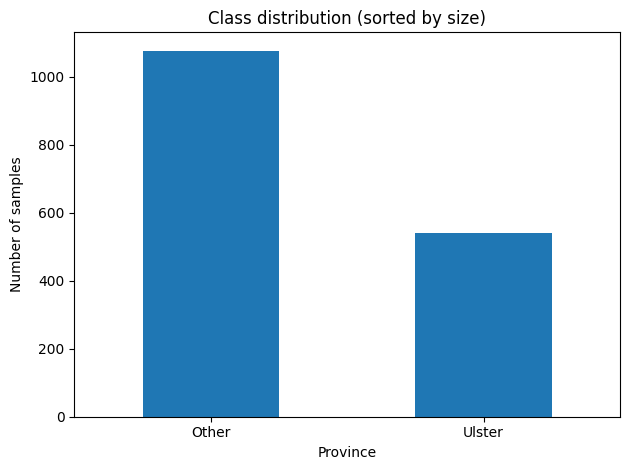

In [35]:
class_counts_sorted = class_counts.sort_values(ascending=False)

print(class_counts_sorted)

class_counts_sorted.plot(kind="bar")
plt.title("Class distribution (sorted by size)")
plt.xlabel("Province")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Cross-validation run + capture predictions

Runs k-fold CV, prints fold reports, and stores all predictions for plots.


In [36]:
labels_sorted = ["Other", "Ulster"]

if USE_GROUP_SPLIT:
    if groups is None:
        raise ValueError("USE_GROUP_SPLIT=True but groups is None. Ensure COL_SPEAKER exists.")
    # cv = GroupKFold(n_splits=N_SPLITS)
    cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    split_iter = cv.split(X, y, groups=groups)
else:
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    split_iter = cv.split(X, y)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", BASELINE_MODEL),
])

all_true, all_pred = [], []
fold_acc = []

for fold_i, (train_idx, test_idx) in enumerate(split_iter, start=1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    pipe.fit(X_train, y_train)
    y_hat = pipe.predict(X_test)

    all_true.extend(list(y_test))
    all_pred.extend(list(y_hat))

    acc = (y_hat == y_test).mean()
    fold_acc.append(acc)

    print(f"Fold {fold_i}/{N_SPLITS}")
    print("Test samples:", len(test_idx))
    print(classification_report(y_test, y_hat, labels=labels_sorted, zero_division=0))

print("=== Overall (all folds combined) ===")
print(classification_report(all_true, all_pred, labels=labels_sorted, zero_division=0))

cm = confusion_matrix(all_true, all_pred, labels=labels_sorted)
print("Confusion matrix (labels in sorted order):")
print(labels_sorted)
print(cm)


Fold 1/5
Test samples: 324
              precision    recall  f1-score   support

       Other       0.81      0.87      0.83       215
      Ulster       0.69      0.59      0.63       109

    accuracy                           0.77       324
   macro avg       0.75      0.73      0.73       324
weighted avg       0.77      0.77      0.77       324

Fold 2/5
Test samples: 323
              precision    recall  f1-score   support

       Other       0.83      0.77      0.80       216
      Ulster       0.60      0.67      0.63       107

    accuracy                           0.74       323
   macro avg       0.71      0.72      0.72       323
weighted avg       0.75      0.74      0.74       323

Fold 3/5
Test samples: 324
              precision    recall  f1-score   support

       Other       0.89      0.90      0.90       215
      Ulster       0.80      0.79      0.79       109

    accuracy                           0.86       324
   macro avg       0.84      0.84      0.84    

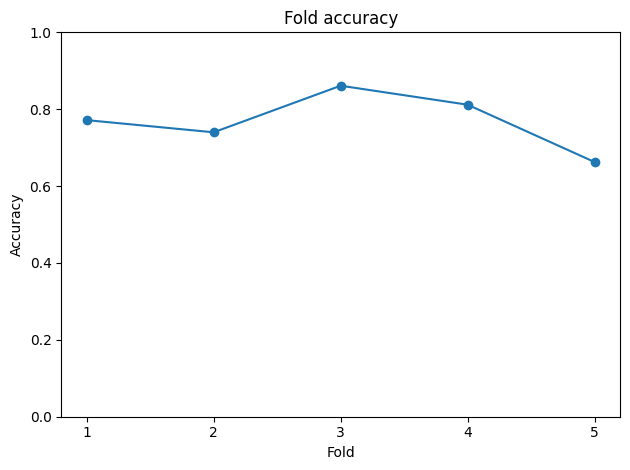

Mean accuracy: 0.7693842449260406
Std accuracy: 0.067074322428426


In [37]:
plt.figure()
plt.plot(range(1, len(fold_acc) + 1), fold_acc, marker="o")
plt.title("Fold accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(range(1, len(fold_acc) + 1))
plt.tight_layout()
plt.show()

print("Mean accuracy:", float(np.mean(fold_acc)))
print("Std accuracy:", float(np.std(fold_acc)))


<Figure size 640x480 with 0 Axes>

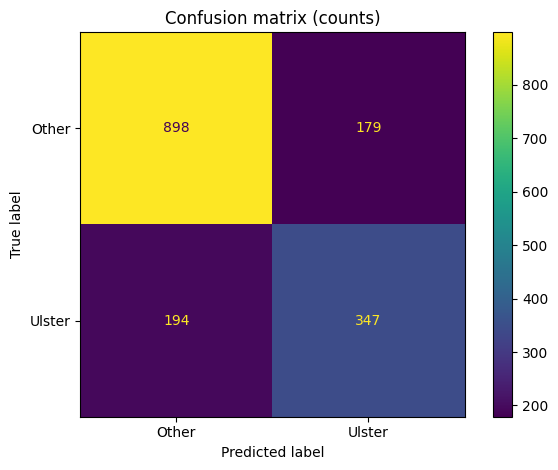

In [38]:
plt.figure()
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
disp.plot(values_format="d")
plt.title("Confusion matrix (counts)")
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

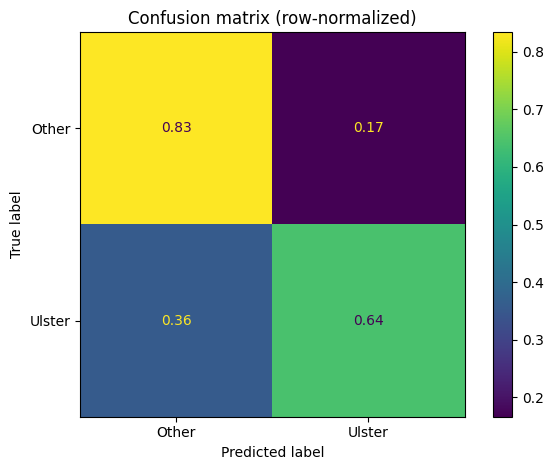

In [39]:
cm_norm = cm.astype(np.float64)
row_sums = cm_norm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_norm, row_sums, out=np.zeros_like(cm_norm), where=row_sums != 0)

plt.figure()
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels_sorted)
disp.plot(values_format=".2f")
plt.title("Confusion matrix (row-normalized)")
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

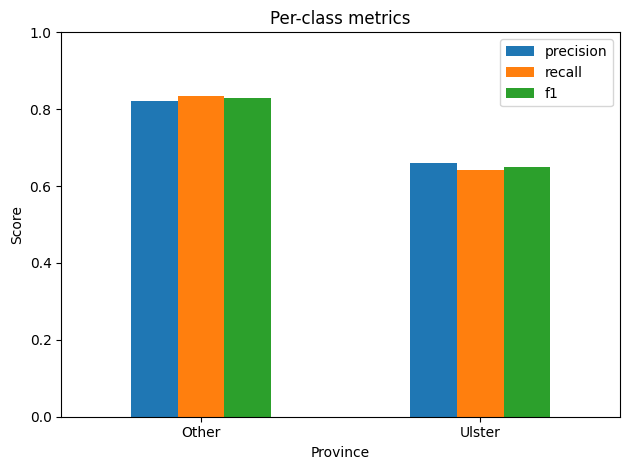

In [40]:
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, sup = precision_recall_fscore_support(
    all_true, all_pred, labels=labels_sorted, zero_division=0
)

metrics_df = pd.DataFrame({
    "precision": prec,
    "recall": rec,
    "f1": f1,
    "support": sup
}, index=labels_sorted)

metrics_df
plt.figure()

metrics_df[["precision", "recall", "f1"]].plot(kind="bar")
plt.title("Per-class metrics")
plt.xlabel("Province")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [41]:
OUT_DIR = Path("notebook_outputs").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

np.savetxt(OUT_DIR / "confusion_matrix_counts.csv", cm, delimiter=",", fmt="%d")
np.savetxt(OUT_DIR / "confusion_matrix_row_normalized.csv", cm_norm, delimiter=",", fmt="%.6f")
metrics_df.to_csv(OUT_DIR / "per_class_metrics.csv")

print("Saved to:", OUT_DIR)


Saved to: /Users/cianan/Documents/College/GitHub/FYP/Prototype2/Scripts/Notebooks/CurrentNotebook/notebook_outputs
